# 2. Sensing & Observation Space

This notebook demonstrates CrowdRL's perception system:
- **Ego state** (7D): goal direction, velocity, heading, torso angle, head angle
- **Social sensing** (K×7D): K nearest neighbours in egocentric frame
- **Raycasts** (N or N×2): head-anchored environment sensing
- **Navmesh signals** (optional, 3D): waypoint direction + path deviation

**Design principle:** One observation builder, used everywhere. The same function
runs in training (`crowdrl-env`) and deployment (`crowdrl-jupedsim`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches
from shapely.geometry import Polygon

from crowdrl_core.geometry import build_navmesh, extract_wall_segments, sample_point_in_polygon
from crowdrl_core.observation import ObsConfig, build_observation, build_observations_batch
from crowdrl_core.sensing import RaycastConfig, cast_rays, knn_social
from crowdrl_core.world_state import WorldState
from crowdrl_env.geometry_generator import GeometryConfig, GeometryTier, generate_geometry
from crowdrl_env.visualiser import (
    plot_agents,
    plot_geometry,
    plot_navmesh,
    plot_raycasts,
    visualise_world_state,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Build a Scenario

Place 8 agents in a bottleneck geometry with varied orientations.

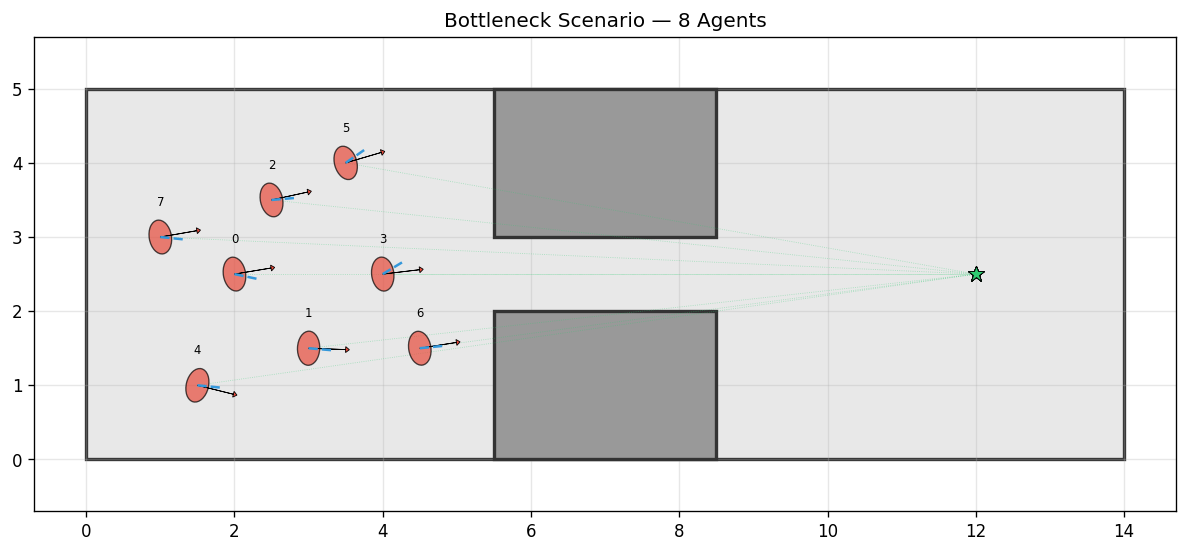

In [2]:
rng = np.random.default_rng(42)

# Create a bottleneck
exterior = [(0, 0), (14, 0), (14, 5), (0, 5)]
top_wall = [(5.5, 3.0), (8.5, 3.0), (8.5, 5.0), (5.5, 5.0)]
bottom_wall = [(5.5, 0.0), (8.5, 0.0), (8.5, 2.0), (5.5, 2.0)]
polygon = Polygon(exterior, [top_wall, bottom_wall])

n_agents = 8
# Agents approaching from the left
positions = np.array([
    [2.0, 2.5], [3.0, 1.5], [2.5, 3.5], [4.0, 2.5],
    [1.5, 1.0], [3.5, 4.0], [4.5, 1.5], [1.0, 3.0],
], dtype=np.float64)

# All heading roughly toward the bottleneck
torso_orientations = rng.uniform(-0.3, 0.3, n_agents)  # ~facing +x
head_orientations = torso_orientations + rng.uniform(-0.5, 0.5, n_agents)
velocities = np.column_stack([
    rng.uniform(0.5, 1.2, n_agents),
    rng.uniform(-0.3, 0.3, n_agents),
])

goal_positions = np.full((n_agents, 2), [12.0, 2.5])

world = WorldState(
    positions=positions,
    velocities=velocities,
    torso_orientations=torso_orientations,
    head_orientations=head_orientations,
    shoulder_widths=np.full(n_agents, 0.23),
    chest_depths=np.full(n_agents, 0.15),
    goal_positions=goal_positions,
    walkable_polygon=polygon,
    wall_segments=extract_wall_segments(polygon),
    navmesh=build_navmesh(polygon),
)

fig, ax = visualise_world_state(world, title="Bottleneck Scenario — 8 Agents")
plt.tight_layout()
plt.show()

## Raycasting

Rays are emitted from the agent's position within a head-anchored field of view.
Each ray returns the normalised distance to the nearest wall or agent.

Key design: **FOV follows the head, not the torso.** This creates a perception–action
trade-off: the agent can scan by turning its head (cheap) without reorienting its body.

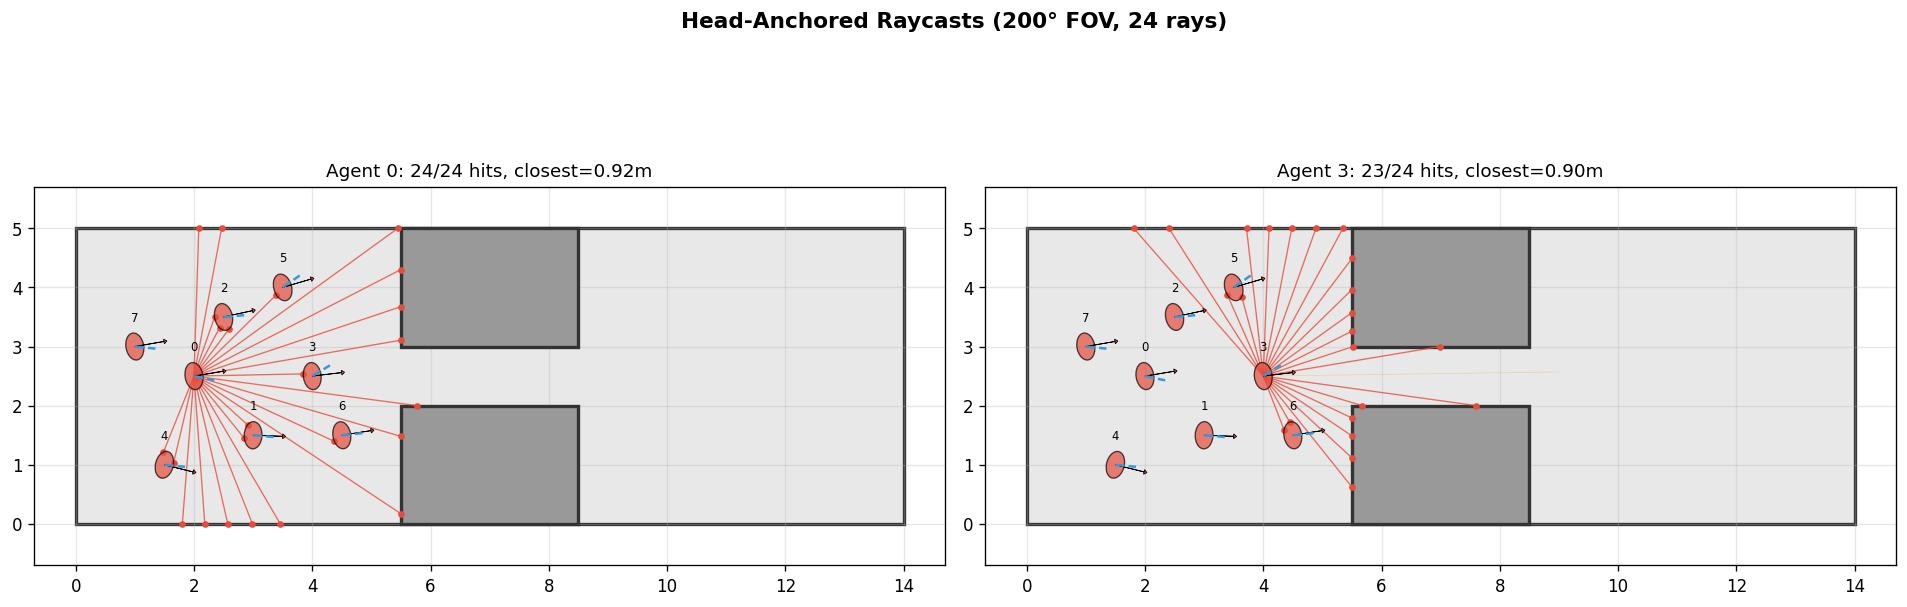

In [3]:
rc_config = RaycastConfig(n_rays=24, fov_deg=200, max_range=5.0)

# Show raycasts for agents 0 and 3
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, agent_idx in zip(axes, [0, 3]):
    readings = cast_rays(world, agent_idx, rc_config)
    plot_geometry(polygon, ax=ax)
    plot_agents(world, ax, show_goals=False, show_ids=True)
    plot_raycasts(world, agent_idx, rc_config, readings, ax)

    n_hits = np.sum(readings < 1.0)
    min_dist = np.min(readings) * rc_config.max_range
    ax.set_title(f"Agent {agent_idx}: {n_hits}/{rc_config.n_rays} hits, closest={min_dist:.2f}m", fontsize=11)

fig.suptitle("Head-Anchored Raycasts (200° FOV, 24 rays)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Raycast Polar Plot

Visualise the ray distances as a polar plot — like a LiDAR scan.

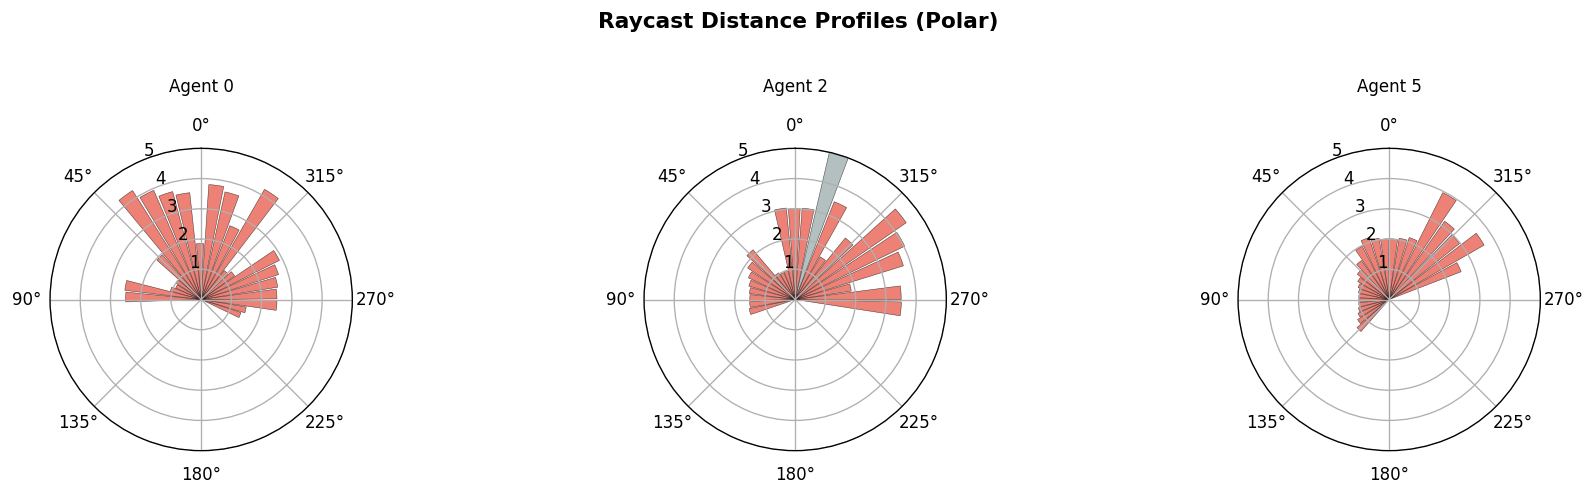

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), subplot_kw={"projection": "polar"})

for ax, agent_idx in zip(axes, [0, 2, 5]):
    readings = cast_rays(world, agent_idx, rc_config)
    head = world.head_orientations[agent_idx]
    fov_rad = np.radians(rc_config.fov_deg)
    angles = np.linspace(head - fov_rad / 2, head + fov_rad / 2, rc_config.n_rays)

    distances = readings * rc_config.max_range
    colors = ["#e74c3c" if d < rc_config.max_range - 0.01 else "#95a5a6" for d in distances]

    ax.bar(angles, distances, width=fov_rad / rc_config.n_rays * 0.9,
           color=colors, alpha=0.7, edgecolor="black", linewidth=0.3)
    ax.set_ylim(0, rc_config.max_range)
    ax.set_title(f"Agent {agent_idx}", fontsize=10, pad=15)
    ax.set_theta_offset(np.pi / 2)

fig.suptitle("Raycast Distance Profiles (Polar)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Social Sensing (K-Nearest Neighbours)

For each of K=8 nearest neighbours, the sensor returns 7 features
in the ego agent's reference frame:
- Relative position (2D)
- Relative velocity (2D)
- Body orientation (1D)
- Body dimensions (2D: shoulder width, chest depth)

In [5]:
agent_idx = 0
social = knn_social(world, agent_idx, k=8)

print(f"Social sensing for Agent {agent_idx} (ego frame):")
print(f"{'Neighbour':>10} {'Rel Pos X':>10} {'Rel Pos Y':>10} {'Rel Vel X':>10} {'Rel Vel Y':>10} {'Orient':>8} {'Width':>7} {'Depth':>7}")
print("-" * 80)
for i in range(8):
    if np.linalg.norm(social[i, :2]) < 1e-6:
        print(f"{'k=' + str(i):>10}  (empty — fewer than {i+1} neighbours)")
        continue
    print(f"{'k=' + str(i):>10} {social[i,0]:10.3f} {social[i,1]:10.3f} {social[i,2]:10.3f} {social[i,3]:10.3f} {social[i,4]:8.3f} {social[i,5]:7.3f} {social[i,6]:7.3f}")

Social sensing for Agent 0 (ego frame):
 Neighbour  Rel Pos X  Rel Pos Y  Rel Vel X  Rel Vel Y   Orient   Width   Depth
--------------------------------------------------------------------------------
       k=0      0.657      0.905      0.158     -0.216    0.051   0.230   0.150
       k=1     -0.905      0.657      0.252      0.073    0.007   0.230   0.150
       k=2      0.823     -1.150     -0.396     -0.289   -0.201   0.230   0.150
       k=3     -0.739     -1.398      0.079     -0.393   -0.408   0.230   0.150
       k=4      1.973     -0.327     -0.019     -0.444   -0.046   0.230   0.150
       k=5      1.725      1.234     -0.148     -0.034    0.121   0.230   0.150
       k=6      2.303     -1.396      0.284     -0.068   -0.008   0.230   0.150
       k=7  (empty — fewer than 8 neighbours)


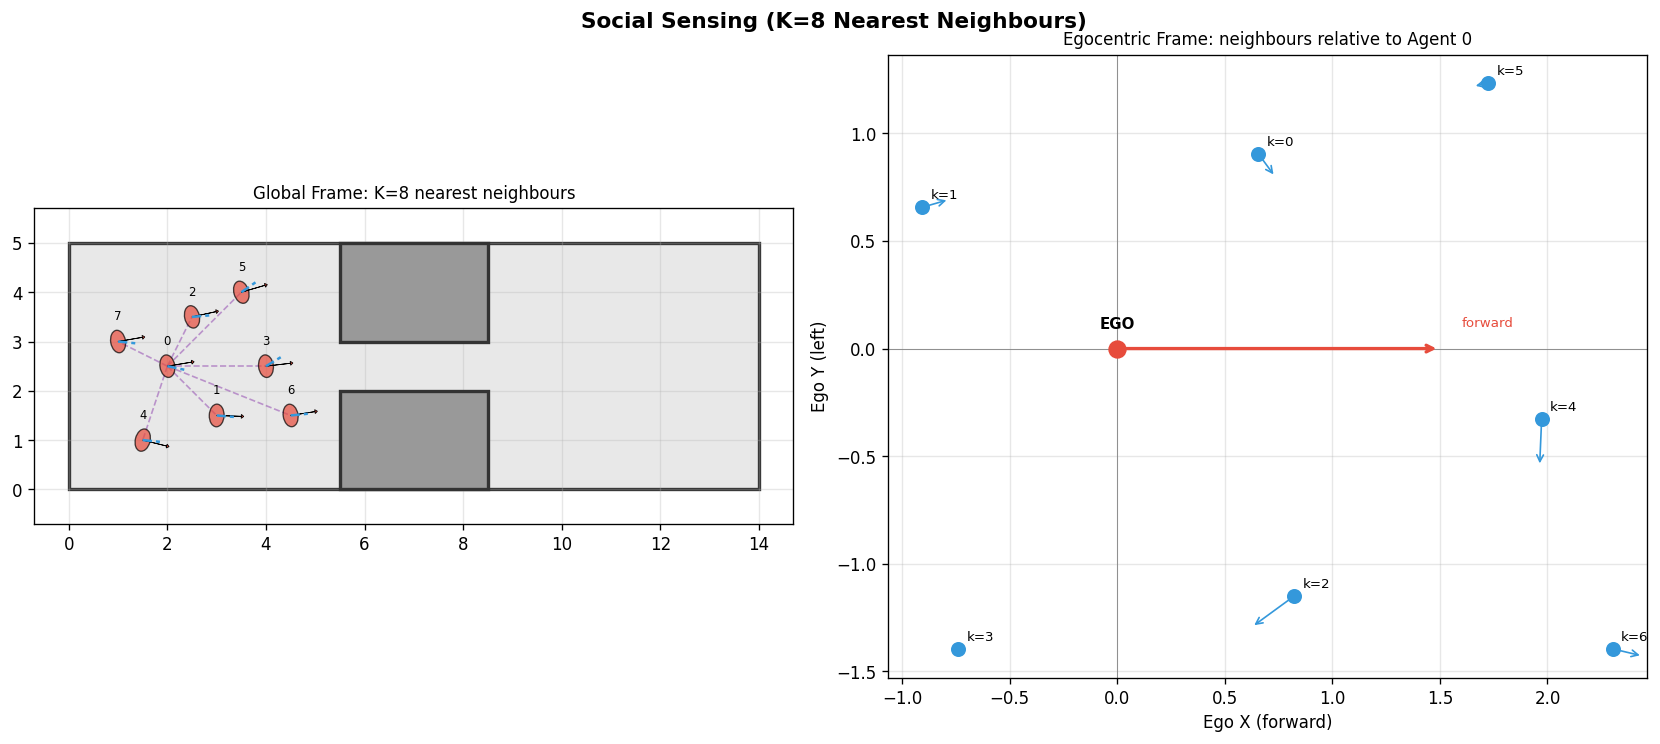

In [6]:
# Visualise social sensing — show the K nearest neighbours from agent 0's perspective
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: global frame
ax = axes[0]
plot_geometry(polygon, ax=ax)
plot_agents(world, ax, show_goals=False)
# Draw lines from ego to neighbours
ego_pos = world.positions[agent_idx]
distances = [np.linalg.norm(world.positions[j] - ego_pos) for j in range(n_agents) if j != agent_idx]
sorted_idx = np.argsort(distances)
other_agents = [j for j in range(n_agents) if j != agent_idx]
for rank, idx in enumerate(sorted_idx[:8]):
    j = other_agents[idx]
    ax.plot([ego_pos[0], world.positions[j, 0]], [ego_pos[1], world.positions[j, 1]],
            "--", color="#9b59b6", linewidth=1.0, alpha=0.6)
ax.set_title("Global Frame: K=8 nearest neighbours", fontsize=10)

# Right: egocentric frame
ax = axes[1]
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)

# Plot ego at origin
ax.plot(0, 0, "o", color="#e74c3c", markersize=10, zorder=10)
ax.annotate("EGO", (0, 0), textcoords="offset points", xytext=(0, 12),
            ha="center", fontsize=9, fontweight="bold")

# Forward direction arrow
ax.annotate("", xy=(1.5, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=2))
ax.text(1.6, 0.1, "forward", fontsize=8, color="#e74c3c")

# Plot neighbours in ego frame
for i in range(8):
    if np.linalg.norm(social[i, :2]) < 1e-6:
        break
    ax.plot(social[i, 0], social[i, 1], "o", color="#3498db", markersize=8, zorder=10)
    ax.annotate(f"k={i}", (social[i, 0], social[i, 1]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
    # Velocity arrow
    ax.annotate("", xy=(social[i, 0] + social[i, 2] * 0.5, social[i, 1] + social[i, 3] * 0.5),
                xytext=(social[i, 0], social[i, 1]),
                arrowprops=dict(arrowstyle="->", color="#3498db", lw=1))

ax.set_title("Egocentric Frame: neighbours relative to Agent 0", fontsize=10)
ax.set_xlabel("Ego X (forward)")
ax.set_ylabel("Ego Y (left)")

fig.suptitle("Social Sensing (K=8 Nearest Neighbours)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Full Observation Vector

The observation builder assembles all components into a single flat vector.
This is **the** function that must be identical between training and deployment.

In [7]:
# Compare different observation configurations
configs = {
    "Default (79D)": ObsConfig(),
    "2-channel rays (95D)": ObsConfig(raycast=RaycastConfig(two_channel=True)),
    "With navmesh (82D)": ObsConfig(use_navmesh=True),
    "Full (98D)": ObsConfig(raycast=RaycastConfig(two_channel=True), use_navmesh=True),
    "Minimal K=4 (51D)": ObsConfig(k_neighbours=4),
}

print(f"{'Config':<25} {'Dim':>5} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8}")
print("-" * 65)
for name, cfg in configs.items():
    obs = build_observation(world, 0, cfg)
    print(f"{name:<25} {cfg.obs_dim:5d} {obs.min():8.3f} {obs.max():8.3f} {obs.mean():8.3f} {obs.std():8.3f}")

Config                      Dim      Min      Max     Mean      Std
-----------------------------------------------------------------
Default (79D)                79   -1.398    2.303    0.202    0.603
2-channel rays (95D)         95   -1.398    2.303    0.231    0.589
With navmesh (82D)           82   -1.398    2.303    0.211    0.598
Full (98D)                   98   -1.398    2.303    0.238    0.584
Minimal K=4 (51D)            51   -1.398    0.987    0.189    0.521


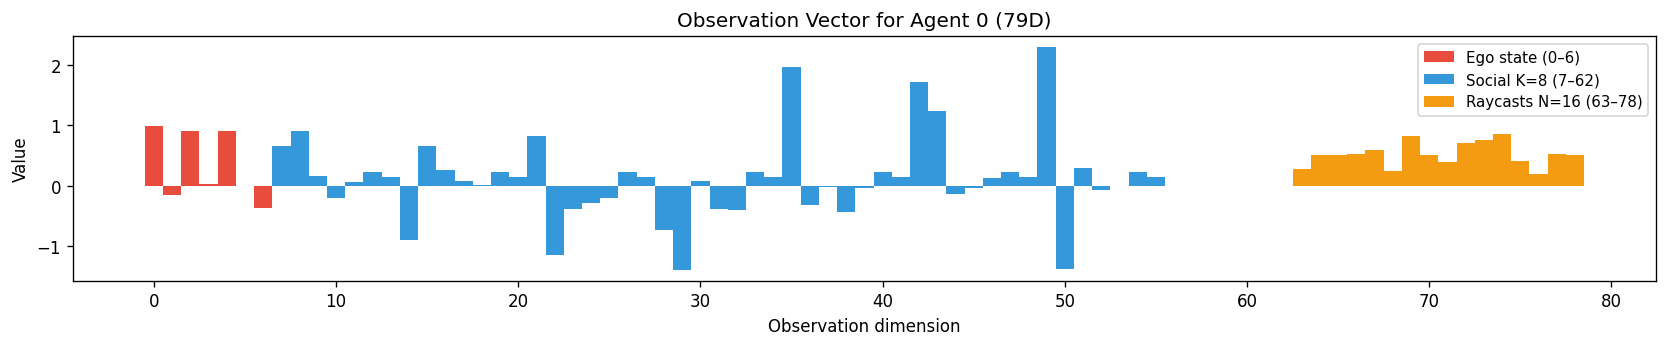

In [8]:
# Visualise observation vector structure
config = ObsConfig()
obs = build_observation(world, 0, config)

fig, ax = plt.subplots(figsize=(14, 3))

# Colour-code components
ego_end = 7
social_end = ego_end + config.k_neighbours * 7
ray_end = social_end + config.raycast.n_rays

colors = (
    ["#e74c3c"] * ego_end +           # Ego state
    ["#3498db"] * (social_end - ego_end) +  # Social
    ["#f39c12"] * (ray_end - social_end)    # Raycasts
)

ax.bar(range(len(obs)), obs, color=colors, width=1.0, edgecolor="none")
ax.set_xlabel("Observation dimension")
ax.set_ylabel("Value")
ax.set_title(f"Observation Vector for Agent 0 ({config.obs_dim}D)")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label=f"Ego state (0–{ego_end-1})"),
    Patch(facecolor="#3498db", label=f"Social K={config.k_neighbours} ({ego_end}–{social_end-1})"),
    Patch(facecolor="#f39c12", label=f"Raycasts N={config.raycast.n_rays} ({social_end}–{ray_end-1})"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## Transfer Guarantee Test

The critical invariant: if WorldState is populated identically (regardless of whether
it comes from `crowdrl-env` or `crowdrl-jupedsim`), the observation vector is identical.

In [9]:
# Simulate the JuPedSim adapter populating WorldState from scratch
world_from_jupedsim = WorldState(
    positions=world.positions.copy(),
    velocities=world.velocities.copy(),
    torso_orientations=world.torso_orientations.copy(),
    head_orientations=world.head_orientations.copy(),
    shoulder_widths=world.shoulder_widths.copy(),
    chest_depths=world.chest_depths.copy(),
    goal_positions=world.goal_positions.copy(),
    walkable_polygon=world.walkable_polygon,
    wall_segments=world.wall_segments.copy(),
    navmesh=world.navmesh,
)

config = ObsConfig()
obs_training = build_observations_batch(world, config)
obs_deployment = build_observations_batch(world_from_jupedsim, config)

max_diff = np.max(np.abs(obs_training - obs_deployment))
print(f"Max observation difference between training and deployment paths: {max_diff}")
assert max_diff == 0.0, "TRANSFER GUARANTEE VIOLATED!"
print("Transfer guarantee holds: observations are numerically identical.")

Max observation difference between training and deployment paths: 0.0
Transfer guarantee holds: observations are numerically identical.
